In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

file_path = r'C:\Users\Prema\Downloads\archive (2)\car data.csv'

df = pd.read_csv(file_path)
print("Data loaded! Here is the first look:")
display(df.head())

Data loaded! Here is the first look:


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [8]:
# 1. Create 'Car_Age' (Current year 2026 - Year of manufacture)
df['Car_Age'] = 2026 - df['Year']

# 2. Drop columns that aren't needed for the model
df.drop(['Year', 'Car_Name'], axis=1, inplace=True)

# 3. Convert categorical text columns (like Fuel_Type) into numbers
df = pd.get_dummies(df, drop_first=True)

print("Data processed! Here is the clean version:")
display(df.head())

Data processed! Here is the clean version:


,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


In [9]:
# Define target (what we want to predict) and features (what we use to predict)
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Check the accuracy (R2 Score)
predictions = model.predict(X_test)
print(f"Model R2 Score: {r2_score(y_test, predictions):.2f}")

Model R2 Score: 0.96


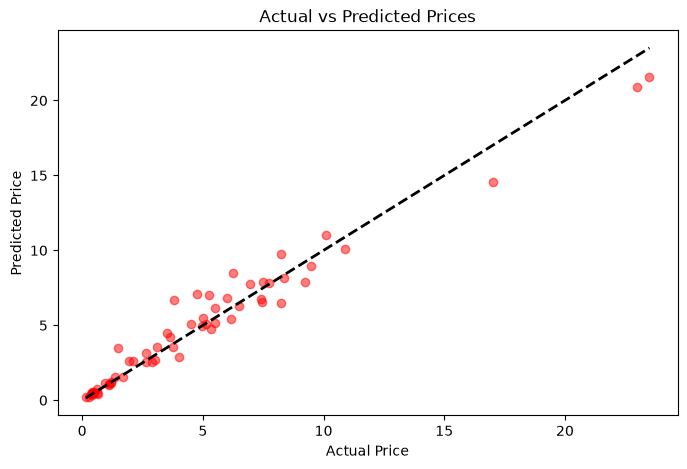

In [10]:
# Final visual step: Compare Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, predictions, color='red', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.show()